In [1]:
import numpy as np
from matplotlib import pyplot as plt 
import math
from scipy import integrate

LENSFOCAL = 502.5 # this is in mm
ZERO_X = 5280/2
ZERO_Y = 4600 /2

In [2]:
bessy= np.loadtxt("bessy.slp")
bessy_slope = bessy [:,1]
def get_data_out(ltp_data):
    return ltp_data[:,0], ltp_data[:,2], ltp_data[:,3]
#print(bessy_slope)
#arrayX = bessy[:,0]

In [9]:
ltp_data = np.loadtxt("FullData12-29_20260907.txt", skiprows = 12)
#ltp_data2 = np.loadtxt("FullData11-42_20260309.txt", skiprows = 12)
#ltp_data3 = np.loadtxt("FullData16-33_20260304.txt", skiprows = 12)
#slope_file = np.loadtxt("Xpos_slopes14-17_20250121.txt", skiprows = 1 )
#slope_data = slope_file[:,1]
#slope_X = slope_file[:,0]
#slopeXpos = slope_X - slope_X[0]
#print(slope_data)
#LTP data is X pos, Y Pos, Average Centroid X, Average Centroid Y, so I need the last column)
myXpos1, avgX1, avgY1 = get_data_out(ltp_data)
#myXpos2, avgX2, avgY2 = get_data_out(ltp_data2)
#myXpos3, avgX3, avgY3 = get_data_out(ltp_data3)

avgX1 = ltp_data[:,2]
avgY1 = ltp_data[:,3]
"""avgX2 = ltp_data2[:,2]
avgY2 = ltp_data2[:,3]"""

#avgX3 = ltp_data2[:,2]
#avgY3 = ltp_data2[:,3]
"""
#print(ltp_data)
myXpos1= ltp_data[:,0]
myXpos2 = ltp_data2[:,0]
myXpos3 = ltp_data3[:,0]"""
x_column = ltp_data[:,0]
diff = x_column[-1] - x_column[0]
#print(diff)
startPos = x_column[0]
Xpos1 = np.arange(0,len(avgX1), 1)


In [4]:
def slope_calc(value, focal):
    slope_error = 0.5 * (math.atan((2.74 * (ZERO_X - value))/(focal* 1000))) # this is in microns, so in µrad? 
    return(slope_error)
def my_fit (arrayX, arrayY, order):
    coeff = np.polyfit(arrayX, arrayY, order)
    p = np.poly1d(coeff)
    fit = p(arrayX)
    radius = 1 /coeff[0]
    return(fit, radius)
def RMS(array):
    RMS = np.sqrt(np.mean(np.square(array)))
    return(RMS)

def figure_error(arrayX, arrayY):
    """
    Calculates the figure error given and array of positions/slopes
    :param arrayX: y-position of the centroid? or X-position of the head?
    :param arrayY: slopes
    :return: an array, heights.
    """

    heights = []
    heights = integrate.cumtrapz(arrayY, arrayX, initial=0)
    return (heights)
    
def analyze_curvature_error(x_mm, alpha_ref_urad, alpha_ltp_urad, f_mm=502.5):
    """
    Determines CMOS adjustment direction by comparing measured vs reference curvature.
    """
    # 1. Local curvature estimation (urad/mm)
    # Filter/Smooth data if it is noisy before taking gradient
    curv_ref = np.gradient(alpha_ref_urad, x_mm)
    curv_ltp = np.gradient(alpha_ltp_urad, x_mm)
    
    c_ref_avg = np.mean(curv_ref)
    c_ltp_avg = np.mean(curv_ltp)
    
    # 2. Scaling error
    m = (c_ltp_avg / c_ref_avg) - 1
    delta_z = -m * f_mm  # Positive m means we move closer (negative delta_z)
    
    print(f"Ref Curvature: {c_ref_avg:.4f} urad/mm")
    print(f"LTP Curvature: {c_ltp_avg:.4f} urad/mm")
    print(f"Scale Error:  {m*100:.3f}%")
    print("-" * 40)
    
    if m > 0:
        print(f"DIAGNOSIS: Extrafocal (Over-estimating curvature).")
        print(f"ACTION: Move CMOS {abs(delta_z):.3f} mm CLOSER to the lens.")
    else:
        print(f"DIAGNOSIS: Intrafocal (Under-estimating curvature).")
        print(f"ACTION: Move CMOS {abs(delta_z):.3f} mm FURTHER from the lens.")
    plt.show()

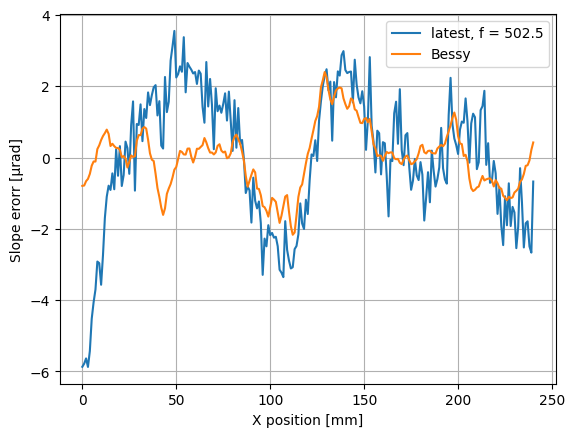

My mirror slope's rms, f = 502:  1.8914593740999197
My mirror slope's rms, f = 502:  0.03014799398675606
bessy heights rms:  0.013914320952660663
Bessy's mirror RMS:  0.8688726611217625


In [10]:
slope_array_502 = np.zeros(len(avgX1))
#slope_array_502_2 = np.zeros(len(avgX2))
#slope_array_502_3 = np.zeros(len(avgX3))

for i in range (len(avgX1)):
    slope_array_502 [i] = slope_calc(avgY1[i], focal = 502.5)
fit_502, radius = my_fit(myXpos1, slope_array_502, 1)
"""for i in range (len(avgX2)):
    slope_array_502_2 [i] = slope_calc(avgY2[i], focal = 502.5)
fit_502_2, radius = my_fit(myXpos2, slope_array_502_2, 1)

for i in range (len(avgX3)):
    slope_array_502_3 [i] = slope_calc(avgY3[i], focal = 502.5)
fit_502_3, radius = my_fit(myXpos3, slope_array_502_3, 1)"""

plt.figure()
plt.plot(Xpos1, (slope_array_502 -fit_502) * 1000000, label = "latest, f = 502.5")
#plt.plot(Xpos2, (slope_array_502_2 -fit_502_2) * 1000000, label = "second latest, f = 502.5")
#plt.plot(Xpos3, (slope_array_502_3 -fit_502_3) * 1000000, label = "latest, f = 502.5")
#plt.plot(Xpos, (slope_array_512 -fit_512) * 1000000, label = "myfit, f = 512")
#plt.plot(Xpos, (slope_array_492 -fit_492) * 1000000, label = "myfit, f = 565")
#plt.plot(Xpos, (slope_array_752 -fit_752) * 1000000, label = "myfit, f = 752.5")

#plt.plot(Xpos/1000, (slope_array - fit) *1000000, label = "myslope - myfit, f = 502.5")
#plt.plot(Xpos/1000, slope_array*1000, label = "slope array, unfitted", marker = "d")
#plt.plot(Xpos, slope_array * 1000, label = "myslope")
plt.plot(Xpos1, bessy_slope, label = "Bessy")

plt.xlabel("X position [mm]")
plt.ylabel("Slope erorr [µrad]")
plt.grid()
plt.legend()
plt.show()
heights = figure_error(Xpos1,slope_array_502 - fit_502 )
rms_heights = RMS(heights)
heights_bessy = figure_error(Xpos1, bessy_slope)
print("My mirror slope's rms, f = 502: ", 1000000*RMS(slope_array_502-fit_502))
print("My mirror slope's rms, f = 502: ",1000*rms_heights)
#print("My mirror slope's 2 rms, f = 502: ", 1000000*RMS(slope_array_502_2-fit_502_2))
#print("My mirror heights's 3 rms, f = 502: ", 1000000*RMS(slope_array_502_3-fit_502_3))
print("bessy heights rms: ", RMS(heights_bessy)/1000)
print("Bessy's mirror RMS: ", RMS(bessy_slope))


In [8]:
myres= slope_array_502 - fit_502
analyze_curvature_error(myres, bessy_slope)

TypeError: analyze_curvature_error() missing 1 required positional argument: 'alpha_ltp_urad'